# Notebook 6: BiLSTM with ESM-2 Embeddings

BLOSUM62 gives every occurrence of an amino acid the same 20-dim vector,
regardless of context. The "A" in one protein looks identical to the "A" in
any other. A protein language model like ESM-2 replaces that static table
with a contextual embedding: the vector for each residue is produced by a
transformer that was pretrained on hundreds of millions of real protein
sequences.

### Design choices
- **Model**: `facebook/esm2_t12_35M_UR50D`: a small ESM-2 checkpoint (35M
  params, 480-dim embeddings). Large enough to be meaningfully pretrained,
  small enough to run embedding extraction on a single GPU in minutes. We can swap
  the string for `esm2_t30_150M_UR50D` (640-dim) for a stronger but slower
  model.
- **Frozen, not fine-tuned**: ESM-2's weights are never updated. We run each
  protein through it once, cache the resulting embeddings to disk, and train
  only the BiLSTM + classifier head on top. Same pattern the literature
  uses, and far cheaper than fine-tuning a transformer end-to-end on 599
  proteins.
- **Everything else** (protein-level split, BiLSTM hyperparameters, training
  protocol, early stopping) is copied from notebook 4 unchanged.


In [2]:
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

df = pd.read_csv("protein_sequences_ss_3.csv")
print(f"Loaded {len(df)} proteins")


Device: cuda
Loaded 599 proteins


In [3]:
# ── Load a frozen, pretrained ESM-2 model ─────────────────────────────────────
MODEL_NAME = "facebook/esm2_t12_35M_UR50D"   # 35M params, 480-dim embeddings

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
esm_model = AutoModel.from_pretrained(MODEL_NAME).to(device)
esm_model.eval()

for p in esm_model.parameters():
    p.requires_grad = False

EMBED_DIM = esm_model.config.hidden_size
n_params  = sum(p.numel() for p in esm_model.parameters())
print(f"Loaded {MODEL_NAME}")
print(f"Embedding dimension: {EMBED_DIM} | Parameters: {n_params:,} (frozen)")


config.json:   0%|          | 0.00/778 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  136MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded facebook/esm2_t12_35M_UR50D
Embedding dimension: 480 | Parameters: 33,500,401 (frozen)


In [4]:
# ── Label encoder + protein-level split (identical to notebook 4) ────────────
le = LabelEncoder()
le.fit(["H", "E", "C"])
print("Classes:", le.classes_)

protein_ids = df.index.tolist()
train_ids, test_ids = train_test_split(protein_ids, test_size=0.2, random_state=42)
train_df = df.iloc[train_ids].reset_index(drop=True)
test_df  = df.iloc[test_ids].reset_index(drop=True)
print(f"Train: {len(train_df)} proteins | Test: {len(test_df)} proteins")


Classes: ['C' 'E' 'H']
Train: 479 proteins | Test: 120 proteins


In [5]:
# ── Extract ESM-2 embeddings once, cache to disk ──────────────────────────────
# ESM-2 is frozen, so its output for a given sequence never changes across
# epochs. Running the transformer once per protein and caching the result
# turns an expensive forward pass into a one-time cost instead of paying it
# on every training epoch.
CACHE_PATH = "esm2_embeddings.pkl"

@torch.no_grad()
def get_esm2_embedding(sequence):
    inputs  = tokenizer(sequence, return_tensors="pt").to(device)
    outputs = esm_model(**inputs)
    # last_hidden_state: (1, seq_len + 2, hidden) — strip the [CLS]/[EOS] tokens
    # the tokenizer adds, so positions line up exactly with the raw sequence.
    return outputs.last_hidden_state[0, 1:-1, :].cpu().numpy()

if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, "rb") as f:
        embedding_cache = pickle.load(f)
    print(f"Loaded {len(embedding_cache)} cached embeddings from {CACHE_PATH}")
else:
    embedding_cache = {}

for _, row in tqdm(df.iterrows(), total=len(df), desc="Extracting ESM-2 embeddings"):
    pid = row["pdb_id"]
    if pid not in embedding_cache:
        emb = get_esm2_embedding(row["sequence"])
        assert emb.shape[0] == len(row["sequence"]), f"Length mismatch for {pid}"
        embedding_cache[pid] = emb

with open(CACHE_PATH, "wb") as f:
    pickle.dump(embedding_cache, f)

print(f"Cached embeddings for {len(embedding_cache)} proteins → {CACHE_PATH}")


Extracting ESM-2 embeddings:   0%|          | 0/599 [00:00<?, ?it/s]

Cached embeddings for 599 proteins → esm2_embeddings.pkl


In [7]:
# ── Dataset (identical structure to notebook 4, ESM-2 embeddings instead of BLOSUM62) 
class ProteinDataset(Dataset):
    def __init__(self, df):
        self.samples = []
        for _, row in df.iterrows():
            x = torch.tensor(embedding_cache[row["pdb_id"]], dtype=torch.float32)
            y = torch.tensor(
                le.transform(list(row["secondary_structure"])),
                dtype=torch.long
            )
            self.samples.append((x, y))

    def __len__(self):             return len(self.samples)
    def __getitem__(self, idx):    return self.samples[idx]


In [8]:
# ── Collate: pad variable-length sequences to batch (identical to notebook 4) 
def collate_fn(batch):
    xs, ys  = zip(*batch)
    lengths = [x.shape[0] for x in xs]
    max_len = max(lengths)

    x_pad = torch.zeros(len(xs), max_len, EMBED_DIM)
    y_pad = torch.full((len(xs), max_len), fill_value=-1, dtype=torch.long)

    for i, (x, y) in enumerate(zip(xs, ys)):
        x_pad[i, :x.shape[0]] = x
        y_pad[i, :y.shape[0]] = y

    return x_pad, y_pad, lengths


In [9]:
# ── Model — same BiLSTM architecture as notebook 4, only input_size changes 
class BiLSTM(nn.Module):
    def __init__(self, input_size=EMBED_DIM, hidden_size=128, num_layers=2,
                 num_classes=3, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.bilstm(x)
        return self.classifier(out)


In [10]:
# ── DataLoaders ────────────────────────────────────────────────────────────────
train_dataset = ProteinDataset(train_df)
test_dataset  = ProteinDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, collate_fn=collate_fn)


In [11]:
# ── Training utilities (identical to notebook 4) ──────────────────────────────
model     = BiLSTM().to(device)
criterion = nn.CrossEntropyLoss(ignore_index=-1)   # -1 = padded positions
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch(model, loader):
    model.train()
    total = 0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x).view(-1, 3), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def compute_loss(model, loader):
    model.eval()
    total = 0
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            total += criterion(model(x).view(-1, 3), y.view(-1)).item()
    return total / len(loader)

def evaluate(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for x, y, lengths in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x).argmax(dim=-1)
            for i, l in enumerate(lengths):
                preds.extend(out[i, :l].cpu().numpy())
                labels.extend(y[i,  :l].cpu().numpy())
    return np.array(preds), np.array(labels)


In [12]:
# ── Training loop with early stopping (identical protocol to notebook 4) ─────
NUM_EPOCHS    = 40
PATIENCE      = 5
best_val_loss = float("inf")
patience_ctr  = 0

train_losses, val_losses, val_accs = [], [], []

for epoch in range(NUM_EPOCHS):
    tr_loss = train_epoch(model, train_loader)

    if (epoch + 1) % 5 == 0:
        vl_loss           = compute_loss(model, test_loader)
        preds, labels_arr = evaluate(model, test_loader)
        acc               = (preds == labels_arr).mean()

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        val_accs.append(acc)

        print(f"Epoch {epoch+1:02d} | Train Loss: {tr_loss:.4f} | "
              f"Val Loss: {vl_loss:.4f} | Accuracy: {acc:.4f}")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            torch.save(model.state_dict(), "bilstm_esm2_best.pt")
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}.")
                break

print("\nTraining complete. Best model saved to bilstm_esm2_best.pt")


Epoch 05 | Train Loss: 0.4913 | Val Loss: 0.4940 | Accuracy: 0.7989
Epoch 10 | Train Loss: 0.4385 | Val Loss: 0.4847 | Accuracy: 0.8000
Epoch 15 | Train Loss: 0.3790 | Val Loss: 0.5249 | Accuracy: 0.7970
Epoch 20 | Train Loss: 0.3140 | Val Loss: 0.5612 | Accuracy: 0.7982
Epoch 25 | Train Loss: 0.2458 | Val Loss: 0.6811 | Accuracy: 0.7896
Epoch 30 | Train Loss: 0.1924 | Val Loss: 0.7601 | Accuracy: 0.7871
Epoch 35 | Train Loss: 0.1406 | Val Loss: 0.9099 | Accuracy: 0.7843

Early stopping at epoch 35.

Training complete. Best model saved to bilstm_esm2_best.pt


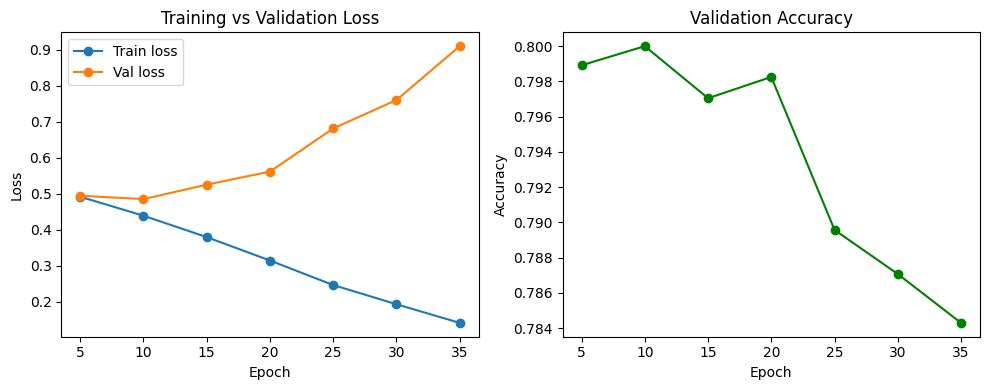

In [13]:
# ── Learning curves ────────────────────────────────────────────────────────────
epochs_logged = list(range(5, 5 * len(train_losses) + 1, 5))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(epochs_logged, train_losses, label="Train loss", marker="o")
ax1.plot(epochs_logged, val_losses,   label="Val loss",   marker="o")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()

ax2.plot(epochs_logged, val_accs, color="green", marker="o")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")

plt.tight_layout()
plt.savefig("learning_curves_bilstm_esm2.png", dpi=150)
plt.show()


In [14]:
# ── Final evaluation (best model) ─────────────────────────────────────────────
model.load_state_dict(torch.load("bilstm_esm2_best.pt", map_location=device))

preds, labels_arr = evaluate(model, test_loader)
print(classification_report(labels_arr, preds, target_names=le.classes_))


/tmp/ipykernel_1705/2516370547.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("bilstm_esm2_best.pt", map_location=device))


              precision    recall  f1-score   support

           C       0.76      0.76      0.76     12974
           E       0.77      0.76      0.77      6537
           H       0.85      0.85      0.85     13698

    accuracy                           0.80     33209
   macro avg       0.79      0.79      0.79     33209
weighted avg       0.80      0.80      0.80     33209



### Comparing to notebook 4 (BiLSTM + BLOSUM62)

Same architecture, same split, same training protocol — the only variable
that changed is the input encoding. That makes the classification reports
directly comparable:

- **If ESM-2 improves things** (expect this, especially on E/strand recall):
  it confirms the hypothesis from our earlier discussion — a lot of the
  long-range, evolutionary context the BiLSTM had to learn from just 480
  training proteins was already captured by ESM-2's pretraining on hundreds
  of millions of sequences, and handed to the BiLSTM for free.
- **Worth checking specifically**: does the BiLSTM's contribution shrink?
  If a simpler downstream head (or even a linear classifier) performs nearly
  as well on ESM-2 embeddings as the full BiLSTM does, that would match what
  the ProtBERT literature found — that a lot of secondary-structure signal is
  already linearly readable straight out of the pretrained embeddings, with
  the BiLSTM adding comparatively little on top.

### Natural next steps from here
- Try a larger checkpoint (`esm2_t30_150M_UR50D`) to see how much embedding
  quality alone moves the needle.
- Concatenate ESM-2 embeddings with BLOSUM62 or a real PSSM, following the
  literature finding that evolutionary profiles and PLM embeddings are
  complementary rather than redundant.
- Unfreeze the last few ESM-2 layers and fine-tune them jointly with the
  BiLSTM head, at a much lower learning rate than the head — the natural
  middle ground between "frozen features" and "train from scratch."
